In [336]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.feature_extraction.text import CountVectorizer

# Import packages for data modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.pipeline import Pipeline















In [337]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")










In [338]:
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [339]:


columns = [
    "claim_status", "video_id", "video_duration_sec", "video_transcription_text",
    "verified_status", "author_ban_status", "video_view_count", "video_like_count",
    "video_share_count", "video_download_count", "video_comment_count"
]

#new Tik-Tok videos
new_rows = [
    {"claim_status": "claim",   "video_transcription_text": "Every year it claims 300,000 lives. That's 30 people every hour. Drowning is one of the world's most overlooked public health issues. And in just 10 years, 3 million people have drowned. And the most heartbreaking part? These deaths are largely preventable. Children are especially vulnerable. Well over half of all drowning deaths are people under 30. And kids under 5 make up almost a quarter of all those cases. The impact isn't the same everywhere. A staggering 92% of drowning deaths happen in low and middle income countries. And the African region is hit the hardest with 5.6 deaths for every 100,000 people. But we can change this. Simple steps can save lives. Teaching kids to swim. Putting up barriers around water. Raring a like jacket whenever boating or fishing. And always keep an eye out on children when water is nearby. But it's not just about what individuals do. Policy matters too. Enforcing boating and very safety laws. Building safer infrastructure. Training first responders. Improving flood disaster preparedness. It all adds up. WHO is leading the way. And coordinates action on drowning prevention across the entire UN system. Because drowning doesn't have to happen."},
    {"claim_status": "claim",   "video_transcription_text": "What's one thing young people need to know about tobacco right now? First, young people need to know that the tobacco industries are technically targeting them. A lot of active users started this addiction in their youth. With stricter regulations nowadays, the tobacco industry is getting very creative with how they market their products to the youth. So there are now a lot of noble addictive products, such as grapes, as cigarettes, and even nicotine pouches that are marketed as so-called cessation devices. These actually trap the youth into a nicotine addiction. And eventually, a lot of these people would be lifelong consumers of the products of the tobacco industry."},
    {"claim_status": "claim", "video_transcription_text": "One in six people around the world feels lonely, and it's not just sad. It's dangerous. Loneliness increases the risk of heart disease, stroke, depression, anxiety, and more. It can actually shorten your life. Something gets a form of self-preservation. You might feel it protects you from feelings like rejection, failure, or embarrassment. You might tell yourself it's safer to stay quiet, isolated, to not take up space. But it also cuts you off from something deeply human, the need to connect. And while making new connections can feel scary at first, what is even scarier is how staying disconnected will harm your physical and mental health."},
    {"claim_status": "opinion", "video_transcription_text": "Do you still believe that 10 years from now, humans will fundamentally be running the world? I'm not sure. It depends on the decisions we all take in the coming years, but there is a chance that the answer is no. That in 10 years, algorithms and AIs will be running the world. I'm not having in mind some kind of Hollywoodian science fiction scenario of one big computer kind of conquering the world. It's more like bureaucracy of AIs that we will have millions of AI bureaucrats everywhere in the banks, in the government, in businesses, in universities, making more and more decisions about our lives. Every day decisions, whether to give us a loan, whether to accept us to a job, and we will find it more and more difficult to understand the logic, the rationale, why the algorithm refused to give us a loan, why the algorithm accepted somebody else for the job. You could still have democracies with people voting for this president or this prime minister, but if most of the decisions are made by AIs and humans, including the politicians, have difficulty understanding the reason why the AIs are making a particular decision, then power will gradually shift from humanity to these new alien intelligences."},
    {"claim_status": "opinion", "video_transcription_text": "I just know that this opinion is gonna piss some people off, but I don't really care. I'm gonna share it anyways. We listen and we don't judge. Sometimes I do get really annoyed and frustrated with people who finally develop their social awareness and it starts to really color their perspective of the world. Like, finally understanding inequality, discrimination, capitalism, fat phobia, pretty privilege. And I'm not trying to say that I'm mad that they're gaining awareness. Like, I think it's better late than never, but it's just like, where have you been? I'm currently in my late 20s and I feel like I've been holding this information and understanding its urgency since like high school. And so it can be kind of jarring to see someone at the same age as me finally go through this. And now that I'm talking it through, I think a large part of my frustration stems from the fact that it's privileged. It's such a big privilege to have been ignorant to all of these issues going on in the world for that many years. And of course those with marginalized identities have been knowing these issues because we've been experiencing it since the beginning of time. But I also want to acknowledge that I understand that it's more the world and society that should be frustrated at rather than individuals. And this is an education issue and as we know, education is not always equitable. It's times like these that I am reminded of the first line in the Great Gatsby. Whenever you feel like criticizing anyone, just remember that all the people in this world haven't had the advantages that you've had. And trying to be more compassionate, remember we listen and we don't judge."},
    {"claim_status": "opinion",   "video_transcription_text": "If we give people handouts, lazy ones will take advantage of the system. That's the point. Why does this bother people so much? I want everyone to have their basic needs covered so that motivated people can actually build what they want to. I want the person who doesn't care about their job out of my workplace. People would still take on extra work to pay for the extra garbage society makes them think that they need. So yes, I want an artist to not worry about food. I want parents to spend more time with their kids. I want homeless people to be housed. That's not laziness. That's freedom."},
    {"claim_status": "opinion", "video_transcription_text": "The people that you love the most, they probably gonna turn their back on you. You gonna find out who your real friends are. You gonna help people and they gonna stab you right in your face, not even in your back. And it's sad, that party's sad, but I'm glad. Cause then I don't have to be with your fake ass for my whole life. You know, cause I love, when I love you, I love you. You know that. Like when I love people, I love them. I show up for them. And I don't wanna show up for nobody that don't really love me."}
]

# מוסיפים ערכי placeholder לכל שורה חדשה בלבד
filled_new_rows = []
for i, row in enumerate(new_rows, start=1):
    full_row = {col: None for col in columns}  # ברירת מחדל NaN
    # ערכי placeholder
    full_row.update({
        "video_id": f"vid_new_{i}",
        "video_duration_sec": 60 + i,
        "verified_status": "Unknown",
        "author_ban_status": "Active",
        "video_view_count": 100 * i,
        "video_like_count": 10 * i,
        "video_share_count": 5 * i,
        "video_download_count": 2 * i,
        "video_comment_count": 3 * i
    })
    # מעדכן גם את הערכים שאתה סיפקת
    full_row.update(row)
    filled_new_rows.append(full_row)

# הופכים ל-DataFrame
df_new = pd.DataFrame(filled_new_rows, columns=columns)

# מחברים לדאטהסט המקורי
data = pd.concat([data, df_new], ignore_index=True)

# שמירה חזרה (אם תרצה לעדכן קובץ)
data.to_csv("tiktok_dataset.csv", index=False)

print(df_new.head())   # מציג רק את השורות החדשות עם הערכים המלאים









  claim_status   video_id  video_duration_sec  \
0        claim  vid_new_1                  61   
1        claim  vid_new_2                  62   
2        claim  vid_new_3                  63   
3      opinion  vid_new_4                  64   
4      opinion  vid_new_5                  65   

                            video_transcription_text verified_status  \
0  Every year it claims 300,000 lives. That's 30 ...         Unknown   
1  What's one thing young people need to know abo...         Unknown   
2  One in six people around the world feels lonel...         Unknown   
3  Do you still believe that 10 years from now, h...         Unknown   
4  I just know that this opinion is gonna piss so...         Unknown   

  author_ban_status  video_view_count  video_like_count  video_share_count  \
0            Active               100                10                  5   
1            Active               200                20                 10   
2            Active               300 

In [340]:


print(data.tail(7))  # מציג את 7 השורות האחרונות


data.info()

        # claim_status   video_id  video_duration_sec  \
19382 NaN        claim  vid_new_1                  61   
19383 NaN        claim  vid_new_2                  62   
19384 NaN        claim  vid_new_3                  63   
19385 NaN      opinion  vid_new_4                  64   
19386 NaN      opinion  vid_new_5                  65   
19387 NaN      opinion  vid_new_6                  66   
19388 NaN      opinion  vid_new_7                  67   

                                video_transcription_text verified_status  \
19382  Every year it claims 300,000 lives. That's 30 ...         Unknown   
19383  What's one thing young people need to know abo...         Unknown   
19384  One in six people around the world feels lonel...         Unknown   
19385  Do you still believe that 10 years from now, h...         Unknown   
19386  I just know that this opinion is gonna piss so...         Unknown   
19387  If we give people handouts, lazy ones will tak...         Unknown   
19388  The 

In [341]:
data.shape

(19389, 12)

In [342]:
data.describe()

,#,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,19389.000000,19091.000000,19091.000000,19091.000000,19091.000000,19091.000000
mean,9691.500000,32.433132,254615.312660,84273.739144,16729.119428,1049.047771,349.188466
std,5595.245794,16.238167,322870.788561,133405.838137,32031.898896,2004.031579,799.518334
min,1.000000,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,18.000000,4934.500000,809.500000,115.000000,7.000000,1.000000
50%,9691.500000,32.000000,9951.000000,3399.000000,716.000000,46.000000,9.000000
75%,14536.750000,47.000000,504211.500000,124983.000000,18209.000000,1155.500000,292.000000
max,19382.000000,67.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [343]:
data.isna().sum()

#                             7
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [344]:
# Drop rows with missing values
data = data.dropna(subset=["claim_status", "video_transcription_text"])


In [345]:
data.duplicated().sum()

0

In [346]:
data["claim_status"].value_counts(normalize=True)


claim_status
claim      0.503431
opinion    0.496569
Name: proportion, dtype: float64

In [347]:
# Create `text_length` column
data['text_length'] = data['video_transcription_text'].str.len()
data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1.0,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2.0,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3.0,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4.0,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5.0,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


In [348]:
data[['claim_status', 'text_length']].groupby('claim_status').mean()


,text_length
claim_status,
claim,95.609198
opinion,83.109916


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


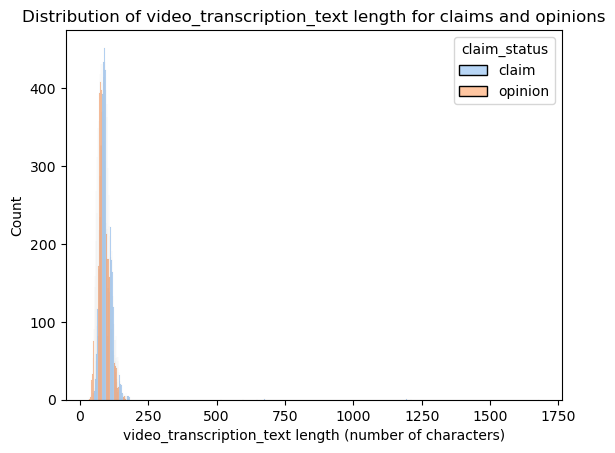

In [349]:
# Visualize the distribution of `video_transcription_text` length for claims and opinions

sns.histplot(data=data, stat="count", multiple="dodge", x="text_length",
             kde=False, palette="pastel", hue="claim_status",
             element="bars", legend=True)
plt.xlabel("video_transcription_text length (number of characters)")
plt.ylabel("Count")
plt.title("Distribution of video_transcription_text length for claims and opinions")
plt.show()


In [350]:
X = data.copy()
# Drop unnecessary columns
X = X.drop(['#', 'video_id'], axis=1)
# Encode target variable
X['claim_status'] = X['claim_status'].replace({'opinion': 0, 'claim': 1})
# Dummy encode remaining categorical values
X = pd.get_dummies(X,
                   columns=['verified_status', 'author_ban_status'],
                   drop_first=True)
X.head()


,claim_status,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_not verified,verified_status_verified,author_ban_status_active,author_ban_status_banned,author_ban_status_under review
0,1,59,someone shared with me that drone deliveries a...,343296.0,19425.0,241.0,1.0,0.0,97,True,False,False,False,True
1,1,32,someone shared with me that there are more mic...,140877.0,77355.0,19034.0,1161.0,684.0,107,True,False,True,False,False
2,1,31,someone shared with me that american industria...,902185.0,97690.0,2858.0,833.0,329.0,137,True,False,True,False,False
3,1,25,someone shared with me that the metro of st. p...,437506.0,239954.0,34812.0,1234.0,584.0,131,True,False,True,False,False
4,1,19,someone shared with me that the number of busi...,56167.0,34987.0,4110.0,547.0,152.0,128,True,False,True,False,False


In [351]:
y = X['claim_status']

In [352]:
# Isolate features
X = X.drop(['claim_status'], axis=1)

# Display first few rows of features dataframe
X.head()

,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_not verified,verified_status_verified,author_ban_status_active,author_ban_status_banned,author_ban_status_under review
0,59,someone shared with me that drone deliveries a...,343296.0,19425.0,241.0,1.0,0.0,97,True,False,False,False,True
1,32,someone shared with me that there are more mic...,140877.0,77355.0,19034.0,1161.0,684.0,107,True,False,True,False,False
2,31,someone shared with me that american industria...,902185.0,97690.0,2858.0,833.0,329.0,137,True,False,True,False,False
3,25,someone shared with me that the metro of st. p...,437506.0,239954.0,34812.0,1234.0,584.0,131,True,False,True,False,False
4,19,someone shared with me that the number of busi...,56167.0,34987.0,4110.0,547.0,152.0,128,True,False,True,False,False


In [353]:
# Split the data into training and testing sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [354]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=0)

In [355]:
# Get shape of each training, validation, and testing set
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((11454, 13), (3818, 13), (3819, 13), (11454,), (3818,), (3819,))

In [356]:
# Set up a `CountVectorizer` object, which converts a collection of text to a matrix of token counts
count_vec = CountVectorizer(ngram_range=(2, 3),
                            max_features=15,
                            stop_words='english')
count_vec

CountVectorizer(max_features=15, ngram_range=(2, 3), stop_words='english')

In [357]:
# Extract numerical features from `video_transcription_text` in the training set
count_data = count_vec.fit_transform(X_train['video_transcription_text']).toarray()
count_data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 1, 0, 0]])

In [358]:
count_data.shape

(11454, 15)

In [359]:

# Place the numerical representation of `video_transcription_text` from training set into a dataframe
count_df = pd.DataFrame(data=count_data, columns=count_vec.get_feature_names_out())

# Display first few rows
count_df.head()

,colleague discovered,colleague learned,colleague read,discussion board,friend learned,friend read,internet forum,learned media,learned news,media claim,news claim,point view,read media,social media,willing wager
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [360]:
# Concatenate `X_train` and `count_df` to form the final dataframe for training data (`X_train_final`)
# Note: Using `.reset_index(drop=True)` to reset the index in X_train after dropping `video_transcription_text`,
# so that the indices align with those in `X_train` and `count_df`
X_train_final = pd.concat([X_train.drop(columns=['video_transcription_text']).reset_index(drop=True), count_df], axis=1)

# Display first few rows
X_train_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_not verified,verified_status_verified,author_ban_status_active,...,friend read,internet forum,learned media,learned news,media claim,news claim,point view,read media,social media,willing wager
0,52,93598.0,52844.0,86.0,175.0,9.0,113,True,False,True,...,0,0,0,0,0,0,0,0,0,0
1,41,10749.0,6097.0,1437.0,10.0,5.0,101,True,False,True,...,0,0,0,0,0,0,0,0,0,0
2,43,118512.0,3543.0,374.0,70.0,29.0,97,True,False,False,...,1,0,0,0,0,0,0,0,0,0
3,7,254122.0,24735.0,4772.0,151.0,43.0,94,True,False,False,...,0,0,0,0,0,0,0,0,0,0
4,25,4466.0,714.0,7.0,3.0,0.0,89,True,False,True,...,0,0,0,0,0,0,0,0,0,1


In [361]:
# Extract numerical features from `video_transcription_text` in the testing set
validation_count_data = count_vec.transform(X_val['video_transcription_text']).toarray()
validation_count_data


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [362]:
# Place the numerical representation of `video_transcription_text` from validation set into a dataframe
validation_count_df = pd.DataFrame(data=validation_count_data, columns=count_vec.get_feature_names_out())
validation_count_df.head()

,colleague discovered,colleague learned,colleague read,discussion board,friend learned,friend read,internet forum,learned media,learned news,media claim,news claim,point view,read media,social media,willing wager
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [363]:
# Concatenate `X_val` and `validation_count_df` to form the final dataframe for training data (`X_val_final`)
# Note: Using `.reset_index(drop=True)` to reset the index in X_val after dropping `video_transcription_text`,
# so that the indices align with those in `validation_count_df`
X_val_final = pd.concat([X_val.drop(columns=['video_transcription_text']).reset_index(drop=True), validation_count_df], axis=1)

# Display first few rows
X_val_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_not verified,verified_status_verified,author_ban_status_active,...,friend read,internet forum,learned media,learned news,media claim,news claim,point view,read media,social media,willing wager
0,6,840639.0,79706.0,26806.0,350.0,160.0,103,True,False,True,...,0,0,0,0,0,0,0,0,0,0
1,41,620828.0,262089.0,42528.0,1116.0,252.0,94,True,False,True,...,0,0,0,0,0,0,0,0,0,0
2,49,631075.0,284311.0,97442.0,1163.0,354.0,95,False,True,False,...,0,0,0,0,0,0,0,0,0,0
3,5,1452.0,11.0,2.0,0.0,0.0,103,False,True,True,...,0,0,0,0,0,0,0,0,0,0
4,17,288810.0,140861.0,10760.0,516.0,163.0,98,True,False,False,...,0,0,0,0,0,0,0,0,0,0


In [364]:
# Extract numerical features from `video_transcription_text` in the testing set
test_count_data = count_vec.transform(X_test['video_transcription_text']).toarray()

# Place the numerical representation of `video_transcription_text` from test set into a dataframe
test_count_df = pd.DataFrame(data=test_count_data, columns=count_vec.get_feature_names_out())

# Concatenate `X_val` and `validation_count_df` to form the final dataframe for training data (`X_val_final`)
X_test_final = pd.concat([X_test.drop(columns=['video_transcription_text']
                                      ).reset_index(drop=True), test_count_df], axis=1)
X_test_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_not verified,verified_status_verified,author_ban_status_active,...,friend read,internet forum,learned media,learned news,media claim,news claim,point view,read media,social media,willing wager
0,36,378176.0,176895.0,55827.0,1837.0,440.0,95,True,False,True,...,0,1,0,0,0,0,0,0,0,0
1,59,3398.0,1155.0,285.0,17.0,6.0,50,True,False,True,...,0,0,0,0,0,0,0,0,0,0
2,13,818483.0,459817.0,126673.0,948.0,219.0,90,True,False,True,...,0,0,0,0,0,0,0,0,0,0
3,25,5874.0,1914.0,149.0,8.0,1.0,90,True,False,True,...,0,0,0,0,0,0,0,0,0,0
4,26,555780.0,106863.0,15348.0,252.0,91.0,72,True,False,True,...,0,0,0,0,0,0,0,0,0,0


In [365]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [5, 7, None],
             'max_features': [0.3, 0.6],
            #  'max_features': 'auto'
             'max_samples': [0.7],
             'min_samples_leaf': [1,2],
             'min_samples_split': [2,3],
             'n_estimators': [75,100,200],
             }

# Define a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1'}

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

In [366]:
%%time
rf_cv.fit(X_train_final, y_train)

CPU times: user 4min 33s, sys: 1.91 s, total: 4min 34s
Wall time: 4min 36s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 200]},
             refit='recall', scoring={'precision', 'f1', 'accuracy', 'recall'})

In [367]:
rf_cv.best_score_

0.9948051948051949

In [368]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': None,
 'max_features': 0.6,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 75}

In [369]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [4,8,12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300, 500]
             }

# Define a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1'}

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')


In [370]:
%%time
xgb_cv.fit(X_train_final, y_train)

CPU times: user 5min 56s, sys: 8.58 s, total: 6min 4s
Wall time: 32.2 s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, 12],
                         'min_child_weight': [3, 5],
                         'n_estimators': [300, 500]},
             refit='recall', scoring={'precision', 'f1', 'accuracy', 'recall'})

In [371]:
xgb_cv.best_score_

0.989090909090909

In [372]:
xgb_cv.best_params_

{'learning_rate': 0.01,
 'max_depth': 4,
 'min_child_weight': 5,
 'n_estimators': 300}

In [373]:
# Use the random forest "best estimator" model to get predictions on the validation set
y_pred = rf_cv.best_estimator_.predict(X_val_final)

In [374]:
y_pred

array([1, 1, 1, ..., 0, 0, 0])

In [375]:
# Display the true labels of the validation set
y_val

7609     1
9278     1
105      1
14274    0
8827     1
        ..
6018     1
6036     1
18340    0
9726     0
15281    0
Name: claim_status, Length: 3818, dtype: int64

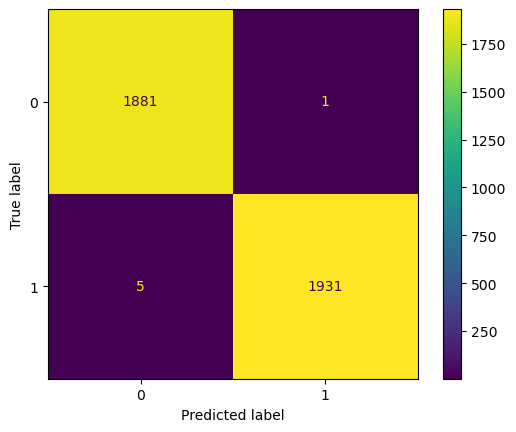

In [376]:
# Create a confusion matrix to visualize the results of the classification model

# Compute values for confusion matrix
log_cm = confusion_matrix(y_val, y_pred)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)

# Plot confusion matrix
log_disp.plot()

# Display plot
plt.show()

In [377]:
# Create classification report for random forest model
target_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       1.00      1.00      1.00      1882
       claim       1.00      1.00      1.00      1936

    accuracy                           1.00      3818
   macro avg       1.00      1.00      1.00      3818
weighted avg       1.00      1.00      1.00      3818



In [378]:
#Evaluate XGBoost model
y_pred = xgb_cv.best_estimator_.predict(X_val_final)

In [379]:
y_pred

array([1, 1, 1, ..., 0, 0, 0])

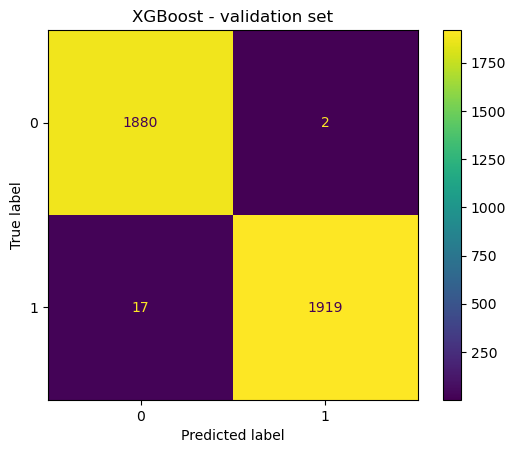

In [380]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_val, y_pred)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)

# Plot confusion matrix
log_disp.plot()

# Display plot
plt.title('XGBoost - validation set');
plt.show()


In [381]:
# Create a classification report
target_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1882
       claim       1.00      0.99      1.00      1936

    accuracy                           1.00      3818
   macro avg       0.99      1.00      1.00      3818
weighted avg       1.00      1.00      1.00      3818



In [382]:
# Use champion model to predict on test data
y_pred = rf_cv.best_estimator_.predict(X_test_final)

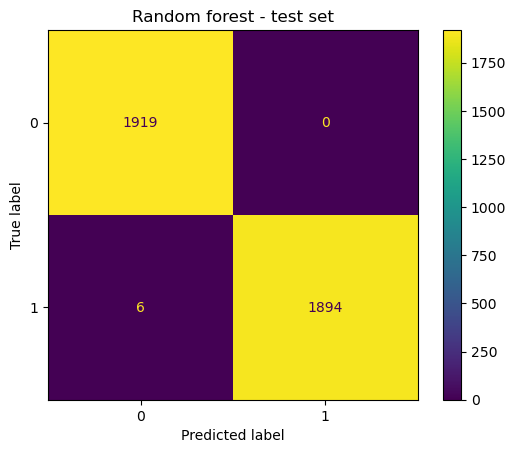

In [383]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)

# Plot confusion matrix
log_disp.plot()

# Display plot
plt.title('Random forest - test set');
plt.show()

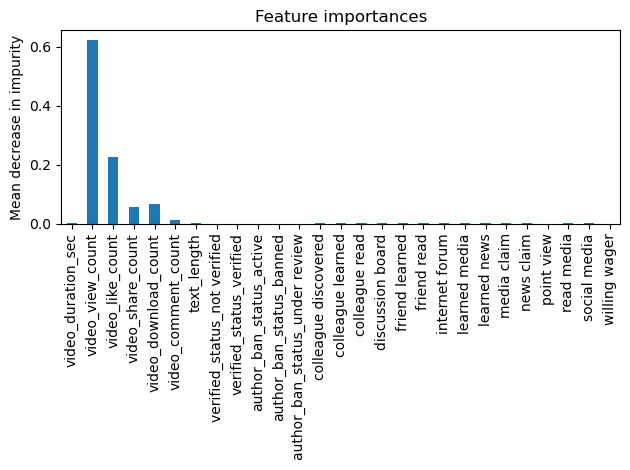

In [384]:
importances = rf_cv.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index=X_test_final.columns)

fig, ax = plt.subplots()
rf_importances.plot.bar(ax=ax)
ax.set_title('Feature importances')
ax.set_ylabel('Mean decrease in impurity')
fig.tight_layout()

In [385]:

TEXT = "video_transcription_text"
LABEL = "claim_status"
y = data[LABEL].replace({"claim": 1, "opinion": 0})
mask = data[TEXT].notna() & y.notna()
pipe = Pipeline([
    ("cv", CountVectorizer(max_features=5000, ngram_range=(1,2))),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
])



In [386]:
pipe.fit(data.loc[mask, TEXT].astype(str), y.loc[mask])
mask_all = data[TEXT].notna() & (data[TEXT].astype(str).str.strip() != "")
probas = pipe.predict_proba(data.loc[mask_all, TEXT].astype(str))
prob_not = probas[:, 0]    # אחוז "לא נכון"
prob_true = probas[:, 1]   # אחוז "נכון"
pred = np.where(prob_true >= 0.5, "True", "False")
results = pd.DataFrame({
    "index": data.index,
    "original_claim_status": data[LABEL],
    "text": data[TEXT].astype(str),   # כאן יש לך את הטקסט המלא
    "Fake news check": pd.Series(pred, index=data.loc[mask_all].index).reindex(data.index),
    "Reliability": (pd.Series(prob_true, index=data.loc[mask_all].index).reindex(data.index)*100).round(2),
    "Unreliability": (pd.Series(prob_not, index=data.loc[mask_all].index).reindex(data.index)*100).round(2),
})

results.to_csv("tiktok_predictions_full.csv", index=False)
print(results.head(10))


   index original_claim_status  \
0      0                 claim   
1      1                 claim   
2      2                 claim   
3      3                 claim   
4      4                 claim   
5      5                 claim   
6      6                 claim   
7      7                 claim   
8      8                 claim   
9      9                 claim   

                                                text Fake news check  \
0  someone shared with me that drone deliveries a...            True   
1  someone shared with me that there are more mic...            True   
2  someone shared with me that american industria...            True   
3  someone shared with me that the metro of st. p...            True   
4  someone shared with me that the number of busi...            True   
5  someone shared with me that gross domestic pro...            True   
6  someone shared with me that elvis presley has ...            True   
7  someone shared with me that the best selling s

In [387]:
def check_text(text):
    proba = pipe.predict_proba([text])[0]
    return {
        "Fake news check": "True" if proba[1] >= 0.5 else "False",
        " Reliability": round(proba[1]*100, 2),
        "Unreliability": round(proba[0]*100, 2)
    }

In [388]:
print(check_text("One in six people around the world feels lonely, and it's not just sad. It's dangerous. Loneliness increases the risk of heart disease, stroke, depression, anxiety, and more. It can actually shorten your life. Something gets a form of self-preservation. You might feel it protects you from feelings like rejection, failure, or embarrassment. You might tell yourself it's safer to stay quiet, isolated, to not take up space. But it also cuts you off from something deeply human, the need to connect. And while making new connections can feel scary at first, what is even scarier is how staying disconnected will harm your physical and mental health."))

{'Fake news check': 'True', ' Reliability': 67.5, 'Unreliability': 32.5}
